# 基于字符级 LSTM 的莎士比亚文本生成

本 notebook 演示如何使用字符级 LSTM（Long Short-Term Memory）语言模型，在莎士比亚全集上进行训练，并生成风格相似的文本。核心思路是：将文本视为字符序列，训练模型在给定前缀字符的条件下预测下一个字符，推理时通过自回归（autoregressive）逐字生成新文本。

## 一、环境配置与依赖导入

In [13]:
import matplotlib as mpl  # 导入 matplotlib 核心模块，提供全局配置接口（如字体、样式设置）
import matplotlib.pyplot as plt  # 导入绘图子模块，plt 是约定别名，用于绘制折线图、散点图等
%matplotlib inline  
# Jupyter 魔法命令：使图表直接嵌入到 notebook 输出区，无需手动调用 plt.show()
import numpy as np  # 导入 NumPy，np 为约定别名，提供高效的多维数组（ndarray）和数学运算支持
import sklearn  # 导入 scikit-learn，提供经典机器学习算法和预处理工具（此处仅用于打印版本号）
import pandas as pd  # 导入 Pandas，pd 为约定别名，提供 DataFrame 结构用于结构化数据处理
import os  # 导入 os 模块，提供与操作系统交互的接口，如路径操作、目录创建（os.makedirs）等
import sys  # 导入 sys 模块，提供访问 Python 解释器信息的接口，如版本号（sys.version_info）
import time  # 导入 time 模块，提供时间相关函数（计时等），此处备用
from tqdm import tqdm  # 从 tqdm 导入自适应进度条：auto 版本可自动选择 notebook 富文本模式或终端文本模式
import torch  # 导入 PyTorch 深度学习框架，是本项目的核心计算引擎
import torch.nn as nn  # 导入神经网络子模块，nn 包含所有网络层类（Embedding、LSTM、Linear 等）
import torch.nn.functional as F  # 导入函数式接口，F 提供无状态操作（softmax、relu 等），不维护参数

print(sys.version_info)  # 打印 Python 版本详细信息（major/minor/micro 字段），便于环境核查
for module in mpl, np, pd, sklearn, torch:  # 遍历主要依赖库列表，逐一确认版本
    print(module.__name__, module.__version__)  # 打印模块名称及版本号，便于实验环境的记录与复现
    
# 检测 GPU 可用性：若系统有 CUDA 支持则使用第 0 块 GPU，否则退回 CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")  # torch.device 对象后续用于将模型和张量移动到指定计算设备
print(device)  # 打印实际使用的计算设备，确认训练在 GPU 还是 CPU 上执行

seed = 42  # 设置随机种子为 42（约定俗成的"宇宙答案"），确保权重初始化等随机过程可复现
torch.manual_seed(seed)  # 固定 PyTorch CPU 端的随机数生成器，影响权重初始化、Dropout 等操作
torch.cuda.manual_seed_all(seed)  # 固定所有 GPU 的随机数生成器，多卡训练时也保证随机性一致

sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、数据准备

### 2.1 下载与读取莎士比亚文集

In [14]:
# !wget https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt  # 使用 shell 命令 wget 从 Google Cloud Storage 下载莎士比亚全集文本（约 1.1 MB）；! 前缀表示在 Jupyter notebook 中执行 shell 命令；文件保存到当前工作目录

In [15]:
# 数据来源：https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt
# 文件已预先下载至本地，直接读取即可
with open("data/shakespeare.txt", "r", encoding="utf8") as file:  # open() 以只读模式（"r"）打开文本文件；encoding="utf8" 指定字符编码，防止中文/特殊字符出现乱码；with 语句确保文件读取完成后自动关闭句柄，避免资源泄漏
    text = file.read()  # file.read() 一次性将文件全部内容读入内存，返回 str 类型的长字符串；约 110 万字符，全部存于 text 变量

print("length", len(text))  # 打印字符串总字符数（约 1115394），验证文件读取完整性
print(text[0:100])  # 打印前 100 个字符，直观预览文本格式和内容（首行为人物对话格式）

length 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


### 2.2 构建字符词汇表与双向映射字典

In [16]:
# 字符级语言模型的数据预处理流程说明：
# 步骤 1：生成词表（vocab）——提取文本中所有不重复的字符，排序后形成固定词表
# 步骤 2：构建映射字典（char2idx）——为每个字符分配唯一整数 ID
# 步骤 3：将原始文本转为整数序列（text_as_int）——神经网络只能处理数值，不能直接处理字符
# 步骤 4：构造训练样本对——输入序列 [a,b,c,d] 对应目标序列 [b,c,d,e]（目标整体右移一位），
#         即模型在看到字符 a 时预测 b，实现"预测下一个字符"的语言模型目标

# set(text) 将字符串拆分为字符集合并自动去重；sorted() 按 ASCII 码升序排列，保证词表顺序固定可复现
vocab = sorted(set(text))  # vocab: list[str]，每个元素为单个字符（长度为 1 的字符串），共 65 种字符
print(len(vocab))  # 打印词表大小：莎士比亚文集共包含 65 种不同字符（含换行符、标点、大小写字母）
print(vocab)  # 打印完整词表，可看到包含 '\n'（换行）、' '（空格）、标点符号和 a-z、A-Z 等字符

65
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [17]:
# 演示 enumerate() 的用法，为下面的字典推导式 {char: idx for idx, char in enumerate(vocab)} 做铺垫
for idx, char in enumerate(['how', 'are', 'you']):  # enumerate(iterable) 接收任意可迭代对象，返回 (index, element) 元组的迭代器；idx 从 0 开始自动递增，char 是对应的元素值
    print(idx, char)  # 打印索引和元素，输出：0 how / 1 are / 2 you；理解此模式后即可理解 char2idx 字典推导式的构建逻辑

0 how
1 are
2 you


In [18]:
# 使用字典推导式为词表中的每个字符分配唯一整数 ID（字符 → 索引的正向映射）
# enumerate(vocab) 产生 (idx, char) 对，字典推导式将 char 作为键、idx 作为值，构建 O(1) 查找的映射
char2idx = {char: idx for idx, char in enumerate(vocab)}  # char2idx: dict[str, int]，如 {'\n': 0, ' ': 1, ..., 'z': 64}；后续将文本每个字符通过此字典转换为对应整数 ID
print(char2idx)  # 打印完整的字符→索引字典，共 65 个键值对，验证每个字符都有唯一编号

{'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}


In [19]:
# 将词表从 Python list 转为 NumPy ndarray，以便支持整数数组批量索引（花式索引）
# 例如：idx2char[np.array([18, 47, 56])] 可一次性还原多个字符，比列表逐元素查找更高效
idx2char = np.array(vocab)  # np.array(list_of_str) 创建一维字符串数组，dtype 为 '<U1'（每元素最多 1 个 Unicode 字符）；idx2char[i] 返回整数 i 对应的字符，是 char2idx 的逆映射
print(idx2char)  # 打印索引→字符的数组：idx2char[0]='\n'，idx2char[1]=' '，...，idx2char[64]='z'

['\n' ' ' '!' '$' '&' "'" ',' '-' '.' '3' ':' ';' '?' 'A' 'B' 'C' 'D' 'E'
 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W'
 'X' 'Y' 'Z' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o'
 'p' 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


In [20]:
# 将整个文本字符串逐字符转换为整数 ID 序列（神经网络的实际输入格式）
# 列表推导式遍历 text 中每个字符 c，通过 char2idx 字典查表得到对应整数 ID
text_as_int = np.array([char2idx[c] for c in text])  # 返回 np.ndarray，dtype=int64，shape=(1115394,)；这是将自然语言文本数字化的关键步骤，后续 Dataset 和模型均基于此整数序列操作
print(text_as_int.shape)  # 打印形状 (1115394,)，即与原文本等长的一维整数数组
print(len(text_as_int))  # 再次打印元素总数 1115394，与 len(text) 相等，验证无字符遗漏
print(text_as_int[0:10])  # 打印前 10 个整数 ID（如 [18, 47, 56, 57, 58, 1, 15, 47, 58, 47]）
print(text[0:10])  # 打印对应的原始字符（"First Citi"），与上方整数对照，手动验证编码正确性

(1115394,)
1115394
[18 47 56 57 58  1 15 47 58 47]
First Citi


### 2.3 构建字符级数据集与批量数据加载器

In [21]:
from torch.utils.data import Dataset, DataLoader  # Dataset 是自定义数据集的抽象基类，必须实现 __len__ 和 __getitem__ 两个接口；DataLoader 封装批次采样、数据打乱、多进程预取等功能

class CharDataset(Dataset):  # 继承 Dataset，定义字符级文本数据集；每个样本为长度 seq_length+1 的字符 ID 子序列
    def __init__(self, text_as_int, seq_length):  # 初始化参数：text_as_int (np.ndarray) 为整个文本的整数编码序列；seq_length (int) 为每个训练样本中输入序列的字符数
        self.sub_len = seq_length + 1  # 每次实际取 seq_length+1 个字符：前 seq_length 个为模型输入，后 seq_length 个为目标（错位一位），+1 确保能同时切出输入和标签
        self.text_as_int = text_as_int  # 保存完整的整数编码文本序列，供 __getitem__ 切片使用
        self.num_seq = len(text_as_int) // self.sub_len  # 整除计算可切出多少个不重叠子序列；末尾不足一个 sub_len 长度的残余字符被丢弃，这是最简单的数据划分策略
        
    def __getitem__(self, index):  # PyTorch Dataset 必须实现的接口，供 DataLoader 按索引取样；参数 index (int)：样本编号，范围 [0, num_seq-1]；返回值：np.ndarray，长度为 sub_len 的字符 ID 子序列
        return self.text_as_int[index * self.sub_len: (index + 1) * self.sub_len]  # 切片获取第 index 个不重叠子序列，起始位置为 index*sub_len，长度固定为 sub_len
    
    def __len__(self):  # PyTorch Dataset 必须实现的接口，返回数据集总样本数；DataLoader 依赖此值做索引边界检查
        return self.num_seq  # 返回不重叠子序列的总数量（即有效训练样本数）
    
def collat_fct(batch):  # 自定义批次整理函数（collate function），替代 DataLoader 的默认 collate_fn；参数 batch (list)：由 DataLoader 收集的一批样本，每个元素是 __getitem__ 返回的 ndarray（长度 sub_len）；返回值：(src_tensor, trg_tensor) 元组
    src_list = []  # 存放每个样本的输入部分（去掉最后一个字符，取前 seq_length 个）
    trg_list = []  # 存放每个样本的目标部分（去掉第一个字符，整体右移一位，取后 seq_length 个）
    for part in batch:  # 遍历批次中每个样本（每个 part 是长度为 sub_len 的字符 ID 数组）
        src_list.append(part[:-1])  # part[:-1] 取前 seq_length 个字符作为输入序列（去掉末尾字符）
        trg_list.append(part[1:])   # part[1:] 取后 seq_length 个字符作为目标序列（去掉首字符），输入和目标错位一位，实现"输入第 t 步字符，预测第 t+1 步字符"的语言模型训练目标
        
    src_list = np.array(src_list)  # 将列表转为二维 ndarray，shape: (batch_size, seq_length)，统一形状后才能转为张量
    trg_list = np.array(trg_list)  # 同上，shape: (batch_size, seq_length)
    return torch.Tensor(src_list).to(dtype=torch.int64), torch.Tensor(trg_list).to(dtype=torch.int64)  # 将 ndarray 转为 PyTorch 张量；dtype=torch.int64 是 nn.Embedding 要求的输入类型（字符索引必须为整数）；返回 (输入张量, 目标标签张量) 元组
        

train_ds = CharDataset(text_as_int, 100)  # 创建训练数据集：seq_length=100 表示每个训练序列含 100 个字符；实际每条样本取 101 个字符（100 作为输入序列，100 作为目标序列，错位一位）
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collat_fct)  # 创建数据加载器：batch_size=64 每批加载 64 条样本；shuffle=True 每轮 epoch 开始前随机打乱样本顺序，防止模型记住数据顺序而过拟合；collate_fn=collat_fct 使用自定义整理函数将样本拆分为输入/目标对并转换为张量

## 三、定义模型

### 3.1 CharLSTM 字符级语言模型定义

In [22]:
class CharLSTM(nn.Module):  # 继承 nn.Module，定义字符级 LSTM 语言模型，将字符 ID 序列映射为下一字符的概率分布
    def __init__(self, vocab_size, embedding_dim=256, hidden_dim=1024):  # 构造函数；vocab_size (int)：词表大小，决定 Embedding 的输入范围和 Linear 的输出维度；embedding_dim (int)：字符嵌入向量的维度，默认 256；hidden_dim (int)：LSTM 隐状态向量的维度，默认 1024
        super(CharLSTM, self).__init__()  # 调用 nn.Module 的父类构造函数，初始化参数注册机制（必须在所有子模块赋值前调用）
        self.embedding = nn.Embedding(vocab_size, embedding_dim)  # 字符嵌入层：将离散整数 ID（范围 [0, vocab_size)）映射为稠密实数向量；本质是一个可学习的查找表（lookup table），形状为 (vocab_size, embedding_dim)；参数量 = 65 × 256 = 16640
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)  # 单层单向 LSTM：input_size=embedding_dim（每时间步输入的向量维度），hidden_size=hidden_dim（隐状态维度）；batch_first=True 使输入张量形状约定为 (batch, seq_len, features)；LSTM 有 4 个门，参数量 ≈ 4×(input_size + hidden_size)×hidden_size
        self.fc = nn.Linear(hidden_dim, vocab_size)  # 全连接输出层：将 LSTM 每个时间步的隐状态（hidden_dim 维）映射到词表大小（vocab_size 维）的 logits；参数量 = hidden_dim × vocab_size + vocab_size = 1024×65 + 65 = 66560
        
    def forward(self, x, hidden=None):  # 前向传播方法；x (torch.Tensor)：形状 (batch, seq_len)，字符 ID 的整数张量；hidden (tuple[torch.Tensor, torch.Tensor] 或 None)：LSTM 的初始隐状态元组 (h_0, c_0)，其中第 0 个元素 h_0 是隐藏状态、第 1 个元素 c_0 是细胞状态（cell state），二者形状均为 (num_layers, batch, hidden_dim)，本模型为单层单向故为 (1, batch, hidden_dim)；传 None 时 PyTorch 自动以全零初始化 h_0 和 c_0；与 nn.RNN 不同，RNN 的 hidden 是单个张量，而 LSTM 必须用元组同时传递 h 和 c；返回 (logits, hidden) 元组
        x = self.embedding(x)  # Embedding 查表：(batch, seq_len) → (batch, seq_len, embedding_dim)；将每个字符 ID 替换为对应的可学习嵌入向量
        output, hidden = self.lstm(x, hidden)  # 调用 nn.LSTM.forward(input, hx)：第二个参数 hx 接受 (h_0, c_0) 元组或 None；返回值 output 形状 (batch, seq_len, hidden_dim)，是每个时间步最后一层的隐状态输出；hidden 为 (h_n, c_n) 元组，h_n 是最后时间步的隐藏状态、c_n 是最后时间步的细胞状态，形状均为 (1, batch, hidden_dim)；自回归生成时将 (h_n, c_n) 原样传入下一步的 hidden 参数，即可跨步维持序列上下文记忆
        x = self.fc(output)  # 线性层：(batch, seq_len, hidden_dim) → (batch, seq_len, vocab_size)；每个时间步的隐状态独立映射为词表上的 logits（未经 softmax 的原始分数）
        return x, hidden  # 返回 (logits, hidden) 元组：logits (torch.Tensor) 形状 (batch, seq_len, vocab_size)，训练时用于计算交叉熵损失；hidden (tuple) 为 (h_n, c_n)，推理时逐步传入 forward 实现有状态自回归生成
    
    
vocab_size = len(vocab)  # 从全局词表获取唯一字符数量（65），作为模型 Embedding 和 Linear 层的维度参数
sample_inputs = torch.randint(0, vocab_size, (2, 100))  # 生成随机整数测试张量：randint(low, high, size) 产生 [0, vocab_size) 范围内的随机整数；形状 (2, 100) 表示 batch_size=2、seq_length=100，用于验证模型 forward 是否正确运行
    
print("{:=^80}".format(" 一层单向 LSTM "))  # 格式化字符串：{:=^80} 表示将字符串居中对齐、宽度 80、用 "=" 填充两侧，生成醒目的分隔标题行
for key, value in CharLSTM(vocab_size).named_parameters():  # named_parameters() 遍历模型所有可学习参数，返回 (参数名, 参数张量) 元组；用于统计和展示各层参数量
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")  # 打印参数名（居中 40 字符宽）和参数量；np.prod(value.shape) 将形状元组各维度相乘得到该层总参数数
    
CharLSTM(vocab_size)(sample_inputs)[0].shape  # 实例化模型并对随机输入执行一次完整前向传播，取返回值第 0 项（logits）并打印形状；期望输出 torch.Size([2, 100, 65])，即 (batch=2, seq_len=100, vocab_size=65)

================================== 一层单向 LSTM ===================================
            embedding.weight            paramerters num: 16640
           lstm.weight_ih_l0            paramerters num: 1048576
           lstm.weight_hh_l0            paramerters num: 4194304
            lstm.bias_ih_l0             paramerters num: 4096
            lstm.bias_hh_l0             paramerters num: 4096
               fc.weight                paramerters num: 66560
                fc.bias                 paramerters num: 65


torch.Size([2, 100, 65])

### 3.2 LSTM 参数量公式推导与验证

In [23]:
4 * 1024 * 256  # 验证 LSTM weight_ih_l0（输入权重矩阵）的参数量：LSTM 有 4 个门（输入门 i、遗忘门 f、细胞门 g、输出门 o），每个门对应一个形状为 (hidden_dim, input_dim) = (1024, 256) 的权重矩阵；总参数量 = 4 × 1024 × 256 = 1,048,576，与上方 named_parameters 输出一致

1048576

In [24]:
4 * 1024 * 1024  # 验证 LSTM weight_hh_l0（循环权重矩阵）的参数量：每个门还有一个形状为 (hidden_dim, hidden_dim) = (1024, 1024) 的循环连接权重（处理上一时间步隐状态 h_{t-1}）；总参数量 = 4 × 1024 × 1024 = 4,194,304；这是 LSTM 中参数量最大的部分，循环连接是其具有序列记忆能力的关键来源，也是 LSTM 训练成本高于前馈网络的原因

4194304

## 四、模型训练

### 4.1 模型检查点保存回调类

In [25]:
class SaveCheckpointsCallback:  # 模型检查点保存回调类；采用"回调（Callback）"设计模式，将检查点逻辑从训练主循环中解耦，训练时像调用函数一样触发
    def __init__(self, save_dir, save_best_only=True):  # 构造函数；save_dir (str)：检查点文件的保存目录路径；save_step (int)：触发保存的步数间隔，默认每 5000 步检查一次；save_best_only (bool)：True 时只保留历史最优模型（覆盖式更新 best.ckpt），False 时每次保存新文件（{step}.ckpt）
        """
        隔回调步保存模型

        Args:
            save_dir (str): dir to save checkpoint
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir  # 保存检查点文件的目标目录（str），供后续 torch.save 拼接完整路径
        self.save_best_only = save_best_only  # 是否只保留最优模型：True 时磁盘始终只有一个 best.ckpt，节省空间
        self.best_metrics = float('-inf')  # 历史最优指标初始化为负无穷，确保第一次满足条件的 metric（通常为 -loss，正值）都能触发保存
        
        # 若保存目录不存在则创建，防止 torch.save 因路径不存在而抛出 FileNotFoundError
        if not os.path.exists(self.save_dir):  # os.path.exists(path) 检查路径是否已存在，返回 bool
            os.makedirs(self.save_dir)  
        
    def __call__(self, step, state_dict, metric=None):  # 实现 __call__ 使类实例可像函数一样调用；step (int)：当前全局训练步数；state_dict (dict)：模型参数字典，由 model.state_dict() 获取，包含所有可学习参数的张量；metric (float 或 None)：用于比较优劣的评估指标（此处传入 -loss，越大表示 loss 越小）
        
        if self.save_best_only:  # 开启"只保留最优模型"模式
            assert metric is not None  # 断言：must_only 模式必须提供 metric 才能比较，否则无从判断优劣
            if metric >= self.best_metrics:  # 若当前指标不低于历史最优（模型性能有所提升或持平），则触发保存
                # 将最新最优模型权重覆盖写入 best.ckpt，始终保留当前最佳状态
                torch.save(state_dict, os.path.join(self.save_dir, "6_model_best.ckpt"))  # torch.save() 将 Python 对象序列化到磁盘（使用 pickle 协议）；os.path.join() 跨平台安全拼接目录和文件名
                # 将当前指标设为新的历史最优，供下次比较使用
                self.best_metrics = metric  # 更新 best_metrics，确保只有更优的模型才能覆盖当前检查点
        else:  # 保存所有检查点模式（不比较优劣，按步数命名保存）
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))  # 以当前步数命名检查点文件（如 1000.ckpt、2000.ckpt），保留完整的训练时间线快照，但磁盘占用较大



### 4.2 训练函数定义与执行

In [26]:
# 封装完整的训练循环逻辑，支持有状态/无状态 LSTM 切换、进度显示和检查点保存
def training(
    model,               # nn.Module，待训练的神经网络模型（此处为 CharLSTM 实例）
    train_loader,        # DataLoader，提供批次化、可随机打乱的训练数据迭代器
    epoch,               # int，训练总轮数（完整遍历训练集的次数）
    loss_fct,            # 损失函数对象（如 nn.CrossEntropyLoss），计算预测与真实标签的差异
    optimizer,           # 优化器对象（如 Adam），根据梯度更新模型参数
    save_ckpt_callback=None,  # 可选的检查点回调对象；None 时不保存检查点，提供 SaveCheckpointsCallback 实例时按其规则保存
    stateful=False       # bool，是否使用有状态（stateful）LSTM：True 时跨批次传递隐状态，需保证数据批次连续（不能 shuffle）；False 时每批次重置隐状态，是更常用的设置
    ):
    record_dict = {           # 初始化训练记录字典，存储每步的 loss 和步数，供后续可视化分析
        "train": [],          # 列表中每个元素为 {"loss": float, "step": int} 字典
    }
    
    global_step = 0           # 全局步数计数器，跨 epoch 累计，用于检查点触发判断和记录
    model.train()             # 切换模型到训练模式：启用 Dropout（若有）、BatchNorm 使用当前批次统计量（若有）；与 model.eval() 相对
    hidden = None             # 初始化 LSTM 隐状态为 None；框架在第一次调用时自动用全零张量初始化 (h_0, c_0)
    with tqdm(total=epoch * len(train_loader),desc="训练进度") as pbar:  # 创建总步数为 epoch×批次数 的进度条；len(train_loader) 是每个 epoch 的批次数
        for epoch_id in range(epoch):  # 外层循环：遍历每个 epoch（完整的数据集过一遍）
            # 内层训练循环：逐批次取数据，执行前向、损失、反向、更新四步
            for datas, labels in train_loader:  # DataLoader 迭代器按批次返回 (输入, 标签) 对；datas 和 labels 形状均为 (batch_size, seq_length)
                datas = datas.to(device)   # 将输入数据移至目标计算设备（GPU/CPU）；模型和数据必须在同一设备才能计算
                labels = labels.to(device) # 将标签同步移至目标设备
                # 每次反向传播前必须清零梯度，否则 PyTorch 默认行为是将梯度累加，导致参数更新方向错误
                optimizer.zero_grad()  # 将模型所有参数的 .grad 属性重置为 0（或 None），避免前一批次的梯度污染
                # 前向传播：stateful=True 时传递上一批次末尾的隐状态，实现跨批次的上下文记忆（但要求数据连续）
                logits, hidden = model(datas, hidden=hidden if stateful else None)  # logits 形状 (batch, seq_len, vocab_size)；hidden=(h_n, c_n) 保存最终隐状态
                # 计算交叉熵损失：先将 logits 和标签展平，合并 batch 和 seq_len 维度
                loss = loss_fct(logits.reshape(-1, vocab_size), labels.reshape(-1))  # logits.reshape(-1, vocab_size) → (batch×seq_len, vocab_size)；labels.reshape(-1) → (batch×seq_len,)；CrossEntropyLoss 内部执行 softmax + log + NLLLoss
                # 反向传播：通过链式法则自动计算损失对所有参数的梯度，结果存入各参数的 .grad 属性
                loss.backward()  # 从输出层向输入层反向传播梯度（自动微分机制，无需手动推导）
                # 优化器根据梯度和自身策略（Adam 含动量和自适应学习率）更新所有可学习参数
                optimizer.step()  # 执行参数更新：param ← param - lr × grad（Adam 内部更复杂，含一阶/二阶矩估计）
 
                loss = loss.cpu().item()  # .cpu() 将 loss 张量从 GPU 搬回 CPU；.item() 将单元素张量转为 Python float，避免保存大量 GPU 张量占用显存
                # 将当前步的 loss 和步数追加到记录列表
                record_dict["train"].append({  # 追加记录字典到 train 列表
                    "loss": loss, "step": global_step  # loss: float 标量；step: int 全局步数
                })
   
                # 触发检查点回调（回调内部按 save_step 判断是否真正保存）
                if save_ckpt_callback is not None:  # 仅在提供了回调对象时才调用，避免 None 调用报错
                    save_ckpt_callback(global_step, model.state_dict(), metric=-loss)  # metric=-loss：将最小化 loss 转换为最大化 metric，使检查点回调的"最优判断"逻辑统一为"metric 越大越好"
                # 全局步数自增，用于下次触发判断
                global_step += 1   # 每处理完一个批次步数加 1
                pbar.update(1)     # 进度条前进 1 步，视觉上反映训练进度
                pbar.set_postfix({"epoch": epoch_id})  # 在进度条末尾实时显示当前 epoch 编号，便于监控训练阶段
        
    return record_dict  # 返回含完整训练损失记录的字典，可用于后续绘图分析训练过程
        

epoch = 100  # 设置训练总轮数为 100，即完整遍历训练数据集 100 次；轮数越多模型越充分学习，但也更容易过拟合

model = CharLSTM(vocab_size=vocab_size)  # 实例化字符级 LSTM 模型；vocab_size=65（莎士比亚文集的唯一字符数）

# 步骤 1：定义交叉熵损失函数，适用于多分类问题（预测下一个字符属于哪个类别）
loss_fct = nn.CrossEntropyLoss(label_smoothing=0.1)  # CrossEntropyLoss 内部集成了 softmax + log + NLLLoss；输入 logits（未经 softmax），直接输出标量损失；分类数为 vocab_size=65
# 步骤 2：定义 Adam 优化器（自适应矩估计，综合了 Momentum 和 RMSProp 的优点）
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # model.parameters() 返回所有可学习参数的迭代器；lr=0.001 是 Adam 默认推荐学习率，通常无需调整即可获得良好效果

save_ckpt_callback = SaveCheckpointsCallback("model_checkpoints/6_model",save_best_only=True)  # 实例化检查点回调：save_best_only=True 只保留 -loss 最高（即 loss 最低）的模型权重到 best.ckpt

model = model.to(device)  # 将模型的所有参数和缓冲区移到目标计算设备（GPU/CPU），必须在训练前执行
record = training(         # 启动训练，返回包含所有步骤损失记录的字典
    model,                 # 已移至 device 的 CharLSTM 实例
    train_dl,              # 字符级训练数据加载器
    epoch,                 # 训练总轮数（100）
    loss_fct,              # 交叉熵损失函数
    optimizer,             # Adam 优化器
    save_ckpt_callback=save_ckpt_callback,  # 检查点保存回调，只保留最优模型
    )

训练进度: 100%|██████████| 17300/17300 [04:04<00:00, 70.87it/s, epoch=99]


### 4.3 训练损失曲线可视化

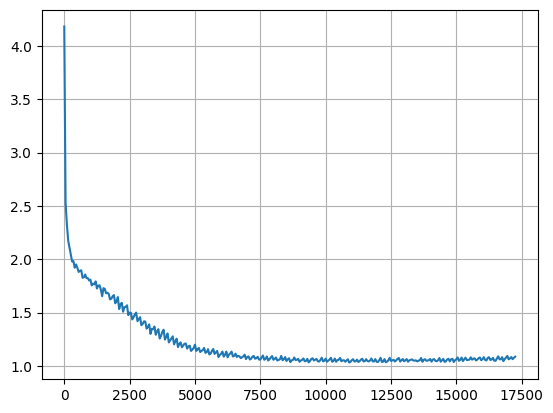

In [27]:
plt.plot([i["step"] for i in record["train"][::50]], [i["loss"] for i in record["train"][::50]], label="train")  # 绘制训练损失折线图：record["train"][::50] 每隔 50 步取一个记录点（降采样，防止图线过密影响可读性）；横轴为全局训练步数（step），纵轴为交叉熵损失（loss）；label="train" 设置图例标签
plt.grid()  # 开启网格线，使各数据点的横纵坐标更易对齐读取
plt.show()  # 渲染并显示图表；在 %matplotlib inline 模式下此行可省略，但显式调用是清晰的编程风格

## 五、推理与文本生成

### 5.1 文本生成函数（带温度采样的自回归推理）

In [32]:
def generate_text(model, start_string, max_len=1000, temperature=1.0, stream=True):  # 基于训练好的 LSTM 自回归地生成文本；model: CharLSTM，已加载权重的模型；start_string (str)：生成的起始提示字符串，模型从此处续写；max_len (int)：最大生成字符数，默认 1000；temperature (float)：采样温度，控制生成的随机性（<1 保守/确定，>1 随机/多样，=1 原始分布）；stream (bool)：True 时逐字实时打印，False 时只返回结果字符串
    input_eval = torch.Tensor([char2idx[char] for char in start_string]).to(dtype=torch.int64, device=device).reshape(1, -1)  # 将起始字符串每个字符转为 ID 列表，构造形状 (1, len(start_string)) 的张量（batch_size=1 表示单条推理）；dtype=int64 匹配 Embedding 层要求，device 确保与模型在同一计算设备
    hidden = None             # 初始化 LSTM 隐状态为 None；首次前向传播时框架自动以全零初始化 (h_0, c_0)
    text_generated = []       # 存储逐步生成的字符 ID 列表，推理完成后批量还原为字符串
    model.eval()              # 切换为推理模式：关闭 Dropout，使 BatchNorm 使用全局统计量（若有）；与 model.train() 相对
    print(start_string, end="")  # 先打印起始提示字符串（end="" 不换行），后续生成字符紧接在其后输出
    with torch.no_grad():     # 禁用梯度计算：推理阶段无需反向传播，节省显存（约减少一半）并提升速度
        for i in range(max_len):        # 自回归循环：每次生成一个字符，共迭代 max_len 次
            logits, hidden = model(input_eval, hidden=hidden)  # 前向传播：以上一步生成的字符（或初始序列）为输入，hidden 传递跨步的上下文记忆（stateful 生成）；logits 形状 (1, seq_len, vocab_size)；hidden 更新为当前步末尾隐状态
            # 温度缩放：调节 logits 分布的"尖锐"程度，控制生成多样性
            logits = logits[0, -1, :] / temperature  # logits[0] 取 batch 的第 0 条；[-1] 取序列最后一个时间步的 logits（形状 vocab_size）；除以 temperature：temperature<1 使高概率字符概率更突出（更保守），temperature>1 使分布更均匀（更随机）
            # 温度采样（multinomial sampling）：按概率分布随机抽取，保留生成多样性（区别于贪心解码 argmax）
            probs = F.softmax(logits, dim=-1)  # softmax 将 logits 转换为概率分布（所有值在 [0,1] 且和为 1）；dim=-1 在 vocab_size 维上归一化
            idx = torch.multinomial(probs, 1).item()  # torch.multinomial(probs, num_samples) 按概率分布随机采样 1 个字符索引（有放回）；.item() 将单元素张量转为 Python int 标量
            input_eval = torch.Tensor([idx]).to(dtype=torch.int64, device=device).reshape(1, -1)  # 将本步采样结果构造为下一步的输入张量，形状 (1, 1)；自回归生成的核心：用当前预测结果作为下一时间步的输入
            text_generated.append(idx)  # 将生成的字符 ID 追加到结果列表，用于最终字符串拼接
            if stream:          # 流式输出模式：实时逐字打印
                print(idx2char[idx], end="", flush=True)  # idx2char[idx] 通过索引还原字符；end="" 不换行保持连续输出；flush=True 强制立即刷新输出缓冲区，确保字符即时显示
    return "".join([idx2char[i] for i in text_generated])  # 将所有生成字符 ID 还原为字符列表，再用 join 拼接为完整字符串并返回


torch.manual_seed(seed)           # 重置 CPU 随机种子，确保每次运行的温度采样结果一致（推理可复现）
torch.cuda.manual_seed_all(seed)  # 重置所有 GPU 随机种子，GPU 上的 multinomial 采样结果同样可复现
# 从磁盘加载训练过程中保存的最优模型权重
model.load_state_dict(torch.load("model_checkpoints/6_model/6_model_best.ckpt", map_location="cpu"))  # torch.load() 反序列化检查点文件为 state_dict 字典；map_location="cpu" 确保即使检查点在 GPU 上保存，也可在 CPU 环境正常加载；load_state_dict() 将权重填充到模型对应的各层参数中
start_string = "I"  # 设置生成起始提示（prompt），模拟莎士比亚剧本中角色对话的开头，模型将续写后续内容
res = generate_text(model, start_string, max_len=1000, temperature=0.5, stream=True)  # 调用生成函数：temperature=0.5（小于 1，生成更保守，倾向于高概率词，语法更规范，但多样性较低）；max_len=1000 生成 1000 个字符；stream=True 实时打印输出

I cal

l thee not.

GLOUCESTER:
I cannot tell: the world is grown so heigh!
Then I should knock, I'll have no hate.

ROMEO:
O blessed labour, my most sovereign liege:
Not I.

Second Senator:
Stay: whence are you, sir?

ESCALUS:
I will the heaven find death, nor though mine ears against
The stones of his country's behelds,
High with my life of service, to the royal blood
Where stabb'd your country.

ISABELLA:
Sir, believe it.

First Citizen:
I say that I had so? for these poor Kate be long
Than always heart with splits before the wind;
Now yet it is my sovereign, whom they may
wash while before it was for lawful choler with kiss;
And she, too desperate, would not go:
But where is Edabnevequre in my breast,
Which thou wilt propagate, to have him so proud?
Had I not draw to pursue me as thy father's son,
It shouldst thou hear some other privilege of
your firm resolve. Deceive she pay a whip do a dishonour nor;
For did you keep a far good ! fellow,
Thou hast our precious sound , that right wo